# Smart Transit — AI-Powered Multimodal Journey Planner
### Algorithmic Prototype Notebook

**University Project Prototype**

This notebook implements and demonstrates the core **algorithmic architecture** of a
multimodal public-transit journey planner for Bangladesh. It is a graph-algorithms
prototype, not a production system, and it does not call any real transit API.

> **Data disclaimer:** No real-time or historical Bangladesh transit API is publicly
> available for this project. All stop names, coordinates, travel times, costs and
> connections used below are a **synthetic demonstration dataset — not real
> operational transit data.** Stop names are inspired by real Dhaka locations purely
> to make the example intuitive; the numbers are invented for illustration.

---


## 1. Project Overview

**Problem.** Commuters in a city like Dhaka rarely have a single-mode option between
an origin and a destination. A realistic journey usually mixes walking, bus, and
(where available) metro rail, possibly with a ride-share/CNG leg. Existing simple
tools mostly optimize a single mode or a single metric (usually time), which does not
reflect how people actually decide between routes (time vs. cost vs. number of
transfers vs. how far they must walk).

**Goal.** Build a prototype that:
1. Represents a city's transit options as a single multimodal graph,
2. Generates several realistic candidate journeys between an origin and a destination,
3. Scores each candidate using multiple criteria (time, cost, transfers, walking
   distance) under a configurable user-preference model, and
4. Recommends a ranked list of journeys, not just one "shortest" path.

**Scope.** This notebook covers the *algorithmic* core only: graph construction,
shortest-path routing, k-shortest-path candidate generation, multi-criteria scoring,
and Pareto analysis. It intentionally does **not** include real-time data feeds,
demand prediction, or any trained ML model — those are listed as future work in
Section 15 so that the "AI" framing of the wider project is not misapplied to
components that are, at this stage, deterministic graph algorithms.

**Architecture (high level).**

```
User Input
   -> Transport Network Representation
   -> Multimodal Graph Construction
   -> Route Generation (Dijkstra + Yen's K-shortest paths)
   -> Multi-Criteria Route Optimization (normalized weighted scoring)
   -> Route Ranking
   -> Recommended Journey
```


## 2. Why Multimodal Routing?

A single-mode planner (e.g. "bus only" or "metro only") has three structural
limitations:

1. **Coverage gap.** No single mode reaches every origin/destination pair directly.
   A commuter almost always needs a short walk to reach a stop, and often a second
   mode to cross the city efficiently.
2. **No transfer awareness.** Single-mode planners cannot represent the *cost* of
   switching modes — waiting time, physical walking between platforms, and the
   cognitive/monetary overhead of a transfer.
3. **Single-metric bias.** Even if a single-mode route is technically optimal for
   time, it may be far more expensive, or involve more transfers, than a rider is
   willing to accept.

A **multimodal graph** solves the coverage and transfer problems by modelling
*every* mode (walk, bus, metro, ride-share/CNG) as edges in one graph, with
transfer edges connecting stops that belong to different mode networks but are
physically close or co-located. A **multi-criteria scoring function** (Section 10)
then solves the single-metric bias by letting the "best" route depend on
configurable user preferences instead of a single hard-coded objective.


## 3. System Architecture

```mermaid
flowchart TD
    A[User Query: Origin, Destination, Preferences] --> B[Origin/Destination Resolution]
    B --> C[Multimodal Transport Network]
    C --> D[Graph Construction - NetworkX DiGraph]
    D --> E[Candidate Route Generation - Yen's K-Shortest Paths over Dijkstra]
    E --> F[Route Metric Extraction: time, cost, transfers, walking]
    F --> G[Multi-Criteria Normalization + Weighted Scoring]
    G --> H[Route Ranking]
    H --> I[Pareto / Trade-off Analysis]
    I --> J[Recommended Journey]
```

If the Mermaid renderer is unavailable in your notebook viewer, here is the same
pipeline as plain text:

```
User Query (origin, destination, preference weights)
        |
        v
Origin/Destination Processing  (map names -> node IDs)
        |
        v
Multimodal Transport Network   (synthetic Dhaka-inspired dataset)
        |
        v
Graph Construction             (NetworkX weighted directed graph)
        |
        v
Candidate Route Generation     (Dijkstra baseline + Yen's K-shortest paths)
        |
        v
Multi-Criteria Evaluation      (normalize time/cost/transfers/walking, weighted sum)
        |
        v
Route Ranking                  (sort candidates by score)
        |
        v
Pareto Analysis                (identify non-dominated trade-off routes)
        |
        v
Recommended Journey
```


## Setup

Only well-established, lightweight dependencies are used: `numpy`, `pandas`,
`networkx`, and `matplotlib`. No installation cell is required in a standard
Jupyter/Colab environment, but the cell below is included for Colab convenience
(it is a no-op if the packages are already present).

A fixed random seed is used everywhere randomness is involved, so the notebook
produces **deterministic** results on every run.


In [1]:
# Uncomment the line below if running in a fresh Google Colab environment
# !pip install -q networkx pandas numpy matplotlib

import random
import itertools
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Environment ready.")
print("networkx version:", nx.__version__)


Environment ready.
networkx version: 3.6.1


## 4. Dataset — Synthetic Bangladesh-Inspired Transit Network

> **Synthetic demonstration dataset — not real operational transit data.**
> Stop names are inspired by real Dhaka-area locations (Uttara, Airport, Banani,
> Mohakhali, Farmgate, Shahbag, Motijheel, Mirpur, Gulshan, Sadarghat) purely so the
> example journey is intuitive to a Bangladeshi reader. The coordinates, travel
> times, costs and connectivity are **invented** for this prototype and must not be
> treated as real schedule, fare, or route information.

We define two tables:

* **`stops`** — every stop/station, its mode, and an approximate (fictionalized)
  lat/lon used only for plotting.
* **`edges`** — directed connections between stops, each tagged with a `mode`
  (`walk`, `bus`, `metro`), a travel time (minutes), a monetary cost (BDT), and a
  distance (km).

Walking edges are generated separately: any two stops within a small synthetic
distance threshold get a bidirectional `walk` edge, representing the ability to
walk between nearby stops (e.g. to transfer between a bus stop and a metro
station that are physically close but operationally separate).


In [2]:
# ---------------------------------------------------------------
# 4.1 Stops table
# ---------------------------------------------------------------
# NOTE: lat/lon values below are simplified/fictionalized approximations used only
# for layout in plots -- they are not authoritative geographic data.

stops_data = [
    # stop_id,   stop_name,     lat,     lon,     mode
    ("UTR_BUS",  "Uttara",      23.8759, 90.3795, "bus"),
    ("UTR_MTR",  "Uttara",      23.8741, 90.3812, "metro"),
    ("AIR_BUS",  "Airport",     23.8433, 90.3978, "bus"),
    ("AIR_MTR",  "Airport",     23.8449, 90.3960, "metro"),
    ("BAN_BUS",  "Banani",      23.7937, 90.4066, "bus"),
    ("MOH_BUS",  "Mohakhali",   23.7806, 90.4046, "bus"),
    ("MOH_MTR",  "Mohakhali",   23.7822, 90.4030, "metro"),
    ("FAR_BUS",  "Farmgate",    23.7580, 90.3894, "bus"),
    ("FAR_MTR",  "Farmgate",    23.7566, 90.3878, "metro"),
    ("SHB_MTR",  "Shahbag",     23.7386, 90.3950, "metro"),
    ("SHB_BUS",  "Shahbag",     23.7398, 90.3966, "bus"),
    ("MTJ_BUS",  "Motijheel",   23.7331, 90.4172, "bus"),
    ("MTJ_MTR",  "Motijheel",   23.7325, 90.4155, "metro"),
    ("MIR_BUS",  "Mirpur",      23.8067, 90.3686, "bus"),
    ("GUL_BUS",  "Gulshan",     23.7925, 90.4147, "bus"),
    ("SAD_BUS",  "Sadarghat",   23.7104, 90.4074, "bus"),
]

stops = pd.DataFrame(stops_data, columns=["stop_id", "stop_name", "lat", "lon", "mode"])
print(f"Total stops: {len(stops)}")
stops


Total stops: 16


,stop_id,stop_name,lat,lon,mode
0,UTR_BUS,Uttara,23.8759,90.3795,bus
1,UTR_MTR,Uttara,23.8741,90.3812,metro
2,AIR_BUS,Airport,23.8433,90.3978,bus
3,AIR_MTR,Airport,23.8449,90.3960,metro
4,BAN_BUS,Banani,23.7937,90.4066,bus
5,MOH_BUS,Mohakhali,23.7806,90.4046,bus
6,MOH_MTR,Mohakhali,23.7822,90.4030,metro
7,FAR_BUS,Farmgate,23.7580,90.3894,bus
8,FAR_MTR,Farmgate,23.7566,90.3878,metro
9,SHB_MTR,Shahbag,23.7386,90.3950,metro


In [3]:
# ---------------------------------------------------------------
# 4.2 Transit edges (bus + metro legs)
# ---------------------------------------------------------------
# Each row: from, to, mode, travel_time (min), cost (BDT), distance (km)
# All numbers are synthetic and invented for this demonstration only.

transit_edges_data = [
    # -------- Metro line (Uttara -> Motijheel), one direction of travel modelled
    # both ways for realism --------
    ("UTR_MTR", "AIR_MTR", "metro", 6,  30, 4.5),
    ("AIR_MTR", "UTR_MTR", "metro", 6,  30, 4.5),
    ("AIR_MTR", "MOH_MTR", "metro", 8,  30, 6.0),
    ("MOH_MTR", "AIR_MTR", "metro", 8,  30, 6.0),
    ("MOH_MTR", "FAR_MTR", "metro", 5,  20, 3.2),
    ("FAR_MTR", "MOH_MTR", "metro", 5,  20, 3.2),
    ("FAR_MTR", "SHB_MTR", "metro", 4,  20, 2.6),
    ("SHB_MTR", "FAR_MTR", "metro", 4,  20, 2.6),
    ("SHB_MTR", "MTJ_MTR", "metro", 5,  20, 3.0),
    ("MTJ_MTR", "SHB_MTR", "metro", 5,  20, 3.0),

    # -------- Bus routes (slower, cheaper, denser coverage) --------
    ("UTR_BUS", "AIR_BUS", "bus", 14, 25, 5.0),
    ("AIR_BUS", "UTR_BUS", "bus", 14, 25, 5.0),
    ("AIR_BUS", "BAN_BUS", "bus", 12, 20, 4.2),
    ("BAN_BUS", "AIR_BUS", "bus", 12, 20, 4.2),
    ("BAN_BUS", "MOH_BUS", "bus", 8,  15, 2.5),
    ("MOH_BUS", "BAN_BUS", "bus", 8,  15, 2.5),
    ("MOH_BUS", "FAR_BUS", "bus", 10, 15, 3.1),
    ("FAR_BUS", "MOH_BUS", "bus", 10, 15, 3.1),
    ("FAR_BUS", "SHB_BUS", "bus", 9,  10, 2.4),
    ("SHB_BUS", "FAR_BUS", "bus", 9,  10, 2.4),
    ("SHB_BUS", "MTJ_BUS", "bus", 11, 15, 3.3),
    ("MTJ_BUS", "SHB_BUS", "bus", 11, 15, 3.3),
    ("MTJ_BUS", "SAD_BUS", "bus", 13, 15, 4.0),
    ("SAD_BUS", "MTJ_BUS", "bus", 13, 15, 4.0),

    # -------- Feeder / connector bus routes to widen coverage --------
    ("UTR_BUS", "MIR_BUS", "bus", 18, 20, 6.5),
    ("MIR_BUS", "UTR_BUS", "bus", 18, 20, 6.5),
    ("MIR_BUS", "FAR_BUS", "bus", 22, 25, 8.0),
    ("FAR_BUS", "MIR_BUS", "bus", 22, 25, 8.0),
    ("BAN_BUS", "GUL_BUS", "bus", 6,  10, 1.8),
    ("GUL_BUS", "BAN_BUS", "bus", 6,  10, 1.8),
    ("GUL_BUS", "MOH_BUS", "bus", 7,  10, 2.0),
    ("MOH_BUS", "GUL_BUS", "bus", 7,  10, 2.0),
]

transit_edges = pd.DataFrame(
    transit_edges_data,
    columns=["from", "to", "mode", "travel_time", "cost", "distance"],
)
print(f"Total transit edges: {len(transit_edges)}")
transit_edges.head(10)


Total transit edges: 32


,from,to,mode,travel_time,cost,distance
0,UTR_MTR,AIR_MTR,metro,6,30,4.5
1,AIR_MTR,UTR_MTR,metro,6,30,4.5
2,AIR_MTR,MOH_MTR,metro,8,30,6.0
3,MOH_MTR,AIR_MTR,metro,8,30,6.0
4,MOH_MTR,FAR_MTR,metro,5,20,3.2
5,FAR_MTR,MOH_MTR,metro,5,20,3.2
6,FAR_MTR,SHB_MTR,metro,4,20,2.6
7,SHB_MTR,FAR_MTR,metro,4,20,2.6
8,SHB_MTR,MTJ_MTR,metro,5,20,3.0
9,MTJ_MTR,SHB_MTR,metro,5,20,3.0


In [4]:
# ---------------------------------------------------------------
# 4.3 Walking edges (generated, not hand-authored)
# ---------------------------------------------------------------
# A walking edge is added between two DIFFERENT stops that share the same
# stop_name (i.e. the same physical area, but different mode platforms -- e.g.
# "Uttara" bus stop and "Uttara" metro station) OR that are within a small
# synthetic distance threshold. Walking speed and a small per-walk boarding-free
# "cost" (0 BDT) are used to derive time/cost/distance for these edges.

WALK_SPEED_KMH = 4.5          # assumed average walking speed
MAX_WALK_DISTANCE_KM = 0.6    # only connect stops within this synthetic distance

def haversine_km(lat1, lon1, lat2, lon2):
    """Standard haversine distance in kilometers."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

walk_edges_data = []
for i, row_a in stops.iterrows():
    for j, row_b in stops.iterrows():
        if row_a.stop_id == row_b.stop_id:
            continue
        same_area = row_a.stop_name == row_b.stop_name
        dist_km = haversine_km(row_a.lat, row_a.lon, row_b.lat, row_b.lon)
        if same_area or dist_km <= MAX_WALK_DISTANCE_KM:
            walk_time_min = max(1, round((dist_km / WALK_SPEED_KMH) * 60))
            walk_edges_data.append(
                (row_a.stop_id, row_b.stop_id, "walk", walk_time_min, 0, round(dist_km, 2))
            )

walk_edges = pd.DataFrame(
    walk_edges_data, columns=["from", "to", "mode", "travel_time", "cost", "distance"]
)
# De-duplicate (same_area pairs can also fall under the distance threshold)
walk_edges = walk_edges.drop_duplicates(subset=["from", "to"]).reset_index(drop=True)

print(f"Total generated walking edges: {len(walk_edges)}")
walk_edges.head(10)


Total generated walking edges: 12


,from,to,mode,travel_time,cost,distance
0,UTR_BUS,UTR_MTR,walk,4,0,0.26
1,UTR_MTR,UTR_BUS,walk,4,0,0.26
2,AIR_BUS,AIR_MTR,walk,3,0,0.26
3,AIR_MTR,AIR_BUS,walk,3,0,0.26
4,MOH_BUS,MOH_MTR,walk,3,0,0.24
5,MOH_MTR,MOH_BUS,walk,3,0,0.24
6,FAR_BUS,FAR_MTR,walk,3,0,0.23
7,FAR_MTR,FAR_BUS,walk,3,0,0.23
8,SHB_MTR,SHB_BUS,walk,3,0,0.21
9,SHB_BUS,SHB_MTR,walk,3,0,0.21


In [5]:
# ---------------------------------------------------------------
# 4.4 Combine into one edge table
# ---------------------------------------------------------------
edges = pd.concat([transit_edges, walk_edges], ignore_index=True)
edges["distance"] = edges["distance"].round(2)
print(f"Total edges in the multimodal network: {len(edges)}")
edges.sample(8, random_state=RANDOM_SEED)


Total edges in the multimodal network: 44


,from,to,mode,travel_time,cost,distance
37,MOH_MTR,MOH_BUS,walk,3,0,0.24
24,UTR_BUS,MIR_BUS,bus,18,20,6.50
25,MIR_BUS,UTR_BUS,bus,18,20,6.50
36,MOH_BUS,MOH_MTR,walk,3,0,0.24
34,AIR_BUS,AIR_MTR,walk,3,0,0.26
40,SHB_MTR,SHB_BUS,walk,3,0,0.21
4,MOH_MTR,FAR_MTR,metro,5,20,3.20
12,AIR_BUS,BAN_BUS,bus,12,20,4.20


## 5. Graph Construction

**Nodes** represent physical stop/station platforms. Note that "Uttara" appears as
*two* nodes (`UTR_BUS`, `UTR_MTR`) because the bus stop and the metro station are
different physical platforms — this is exactly why a `walk` edge is needed between
them to model a real transfer.

**Edges** are directed and carry these attributes:

| Attribute | Meaning |
|---|---|
| `mode` | `walk`, `bus`, or `metro` |
| `time` | travel time in minutes for that leg |
| `cost` | monetary cost in BDT for that leg |
| `distance` | physical distance in km for that leg |

We use a **weighted directed graph** (`nx.DiGraph`) rather than an undirected graph
because, in a real network, travel time/cost/frequency can differ by direction
(e.g. one-way roads, peak-direction bus frequency). All edges here happen to be
defined symmetrically for simplicity, but the data model supports asymmetry.

A **transfer penalty** is not encoded as a separate edge type; instead it is
captured implicitly by counting **mode changes along a path** in the metrics stage
(Section 9) — this keeps the graph simple (only 3 edge "modes") while still letting
the multi-criteria scorer penalize routes with many transfers.


In [6]:
def build_graph(edge_df: pd.DataFrame) -> nx.DiGraph:
    """Build a weighted directed multimodal transit graph from an edge table."""
    G = nx.DiGraph()
    for _, stop in stops.iterrows():
        G.add_node(stop.stop_id, name=stop.stop_name, mode=stop["mode"],
                   lat=stop.lat, lon=stop.lon)
    for _, e in edge_df.iterrows():
        # If a duplicate (from, to) edge exists, keep the faster one.
        if G.has_edge(e["from"], e["to"]):
            if e["travel_time"] >= G[e["from"]][e["to"]]["time"]:
                continue
        G.add_edge(
            e["from"], e["to"],
            mode=e["mode"], time=float(e["travel_time"]),
            cost=float(e["cost"]), distance=float(e["distance"]),
        )
    return G

G = build_graph(edges)
print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} directed edges.")


Graph built: 16 nodes, 44 directed edges.


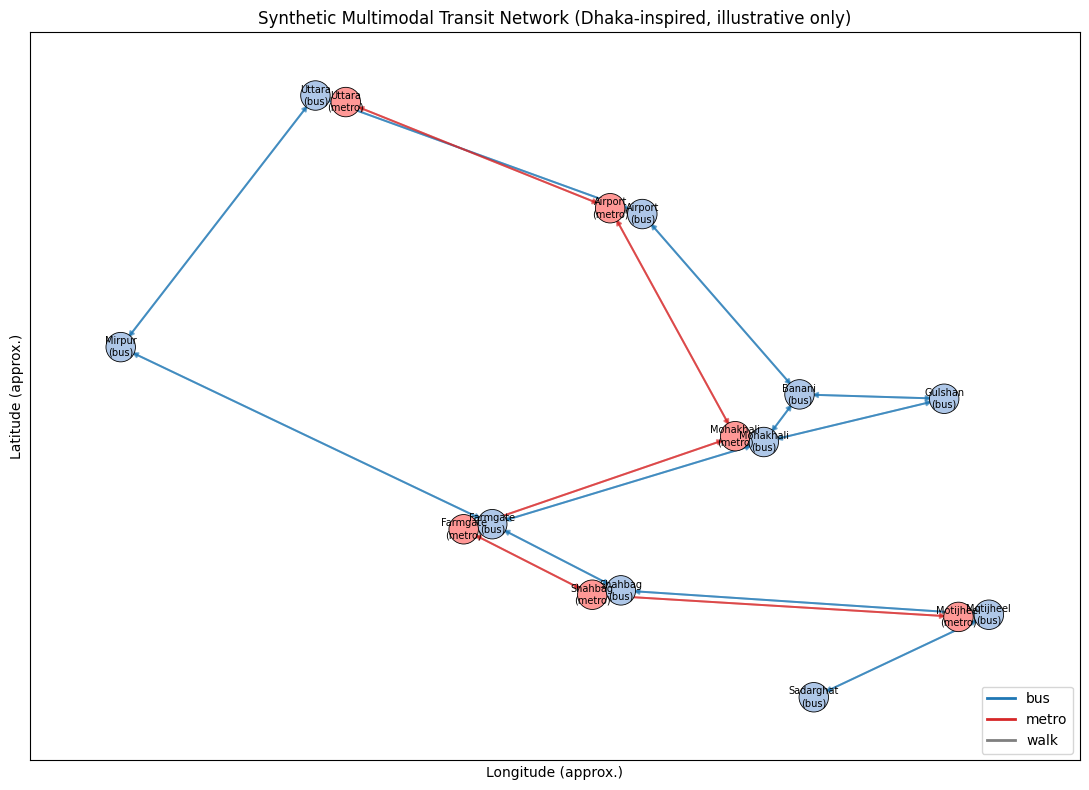

In [7]:
# ---------------------------------------------------------------
# 5.1 Visualize the network, colored by mode
# ---------------------------------------------------------------
mode_colors = {"bus": "#1f77b4", "metro": "#d62728", "walk": "#7f7f7f"}
node_colors = {"bus": "#aec7e8", "metro": "#ff9896", "walk": "#c7c7c7"}

pos = {n: (d["lon"], d["lat"]) for n, d in G.nodes(data=True)}

plt.figure(figsize=(11, 8))
for mode, color in mode_colors.items():
    mode_edges = [(u, v) for u, v, d in G.edges(data=True) if d["mode"] == mode]
    nx.draw_networkx_edges(
        G, pos, edgelist=mode_edges, edge_color=color, alpha=0.6,
        width=1.4 if mode != "walk" else 0.8,
        style="solid" if mode != "walk" else "dashed",
        arrows=True, arrowsize=8, label=mode,
    )

node_fill = [node_colors[d["mode"]] for _, d in G.nodes(data=True)]
nx.draw_networkx_nodes(G, pos, node_color=node_fill, node_size=450, edgecolors="black", linewidths=0.6)
nx.draw_networkx_labels(
    G, pos,
    labels={n: f"{d['name']}\n({d['mode']})" for n, d in G.nodes(data=True)},
    font_size=7,
)

handles = [plt.Line2D([0], [0], color=c, lw=2, label=m) for m, c in mode_colors.items()]
plt.legend(handles=handles, loc="lower right")
plt.title("Synthetic Multimodal Transit Network (Dhaka-inspired, illustrative only)")
plt.xlabel("Longitude (approx.)")
plt.ylabel("Latitude (approx.)")
plt.tight_layout()
plt.show()


## 6. Baseline Routing: Dijkstra's Algorithm

### What it does
Given a weighted graph and a source node, Dijkstra's algorithm computes the
minimum-total-weight path from the source to every other reachable node (or to one
specific target, if we stop early once the target is popped).

### Why we use it
Our edge weight (here, `time`) is **always non-negative** — a bus, metro, or walking
leg can never take negative time. This is precisely the assumption Dijkstra
requires for correctness. Given that assumption holds, Dijkstra is the standard,
well-understood, and provably optimal choice for single-source shortest paths on
a static graph snapshot.

### How it works
Dijkstra maintains a set of "settled" nodes with known-final shortest distance, and
repeatedly selects the unsettled node with the smallest tentative distance
(using a min-priority-queue/heap), relaxing its outgoing edges. Because all weights
are non-negative, once a node is popped from the heap with its current tentative
distance, that distance can be proven final — no later relaxation could ever
produce something smaller, because doing so would require traversing an edge with
negative weight.

### Complexity
With a binary heap, Dijkstra runs in **O((V + E) log V)** time and **O(V)** extra
space, where V is the number of stops and E is the number of directed edges — very
efficient for a city-scale multimodal graph (thousands of stops/edges).

### Why not other classic algorithms, for this specific step
- **BFS** finds the path with the *fewest edges*, not the path with minimum total
  time/cost. Since our edges have different weights (a 1-minute walk edge and a
  20-minute bus edge count equally in BFS), BFS would frequently pick a route that
  is objectively worse for the traveler. BFS is only optimal for **unweighted**
  graphs.
- **DFS** does not compute shortest paths at all; it simply explores as deep as
  possible along one branch before backtracking, giving no optimality guarantee
  and no meaningful "distance" semantics for a weighted graph.
- **Bellman-Ford** handles negative edge weights (and detects negative cycles), but
  at O(V·E) it is strictly slower than Dijkstra, and our problem *never* has
  negative weights (time, cost, and distance are all naturally non-negative), so
  paying for Bellman-Ford's generality would be wasted cost.
- **A\*** could be preferable to plain Dijkstra when we have a good admissible
  heuristic — e.g. straight-line (haversine) distance divided by an average
  speed as a lower bound on remaining time — because it can prune the search space
  and reach the answer faster for a single source/target query. For a small
  demonstration network the difference is negligible, but at true city scale (tens
  of thousands of nodes) A\* with a geographic heuristic would be a natural upgrade
  over plain Dijkstra for single-pair queries.


In [8]:
def resolve_stop(name_or_id: str, mode: Optional[str] = None) -> str:
    """Resolve a human-readable stop name (or an exact stop_id) to a stop_id.

    If multiple platforms share the same name (e.g. 'Uttara' has a bus and a metro
    node), the caller may disambiguate with `mode`; otherwise the first match is
    used.
    """
    if name_or_id in G.nodes:
        return name_or_id
    matches = stops[stops.stop_name.str.lower() == name_or_id.lower()]
    if mode is not None:
        matches = matches[matches["mode"] == mode]
    if matches.empty:
        raise ValueError(f"Unknown stop or station: {name_or_id!r}")
    return matches.iloc[0].stop_id


def dijkstra_route(graph: nx.DiGraph, origin: str, destination: str,
                    weight: str = "time") -> Tuple[List[str], float]:
    """Baseline single-objective shortest path using Dijkstra (via NetworkX).

    Raises nx.NetworkXNoPath if no path exists, and nx.NodeNotFound if either
    endpoint is missing from the graph -- both are handled by the caller.
    """
    path = nx.dijkstra_path(graph, origin, destination, weight=weight)
    length = nx.dijkstra_path_length(graph, origin, destination, weight=weight)
    return path, length


# --- Example: fastest route from Uttara to Motijheel -------------------------
try:
    origin_id = resolve_stop("Uttara", mode="metro")
    dest_id = resolve_stop("Motijheel", mode="metro")
    path, total_time = dijkstra_route(G, origin_id, dest_id, weight="time")
    print("Fastest path (by time) node sequence:")
    print(" -> ".join(f"{n} ({G.nodes[n]['name']}/{G.nodes[n]['mode']})" for n in path))
    print(f"Total time: {total_time:.1f} minutes")
except (nx.NetworkXNoPath, nx.NodeNotFound, ValueError) as exc:
    print(f"Routing error: {exc}")


Fastest path (by time) node sequence:
UTR_MTR (Uttara/metro) -> AIR_MTR (Airport/metro) -> MOH_MTR (Mohakhali/metro) -> FAR_MTR (Farmgate/metro) -> SHB_MTR (Shahbag/metro) -> MTJ_MTR (Motijheel/metro)
Total time: 28.0 minutes


## 7. Multimodal Route Representation

A route is not just a sequence of node IDs — for planning purposes we need the
sequence of **modes used** along the way, so a human-readable itinerary such as
*Walk → Bus → Walk → Metro → Walk* can be produced. The helper below converts a
raw node-path into a labelled list of legs, each with its mode and per-leg
metrics, by reading the edge data directly off the graph.


In [9]:
@dataclass
class Leg:
    frm: str
    to: str
    mode: str
    time: float
    cost: float
    distance: float

@dataclass
class Route:
    path: List[str]                 # sequence of node IDs
    legs: List[Leg] = field(default_factory=list)

    @property
    def total_time(self) -> float:
        return sum(leg.time for leg in self.legs)

    @property
    def total_cost(self) -> float:
        return sum(leg.cost for leg in self.legs)

    @property
    def total_distance(self) -> float:
        return sum(leg.distance for leg in self.legs)

    @property
    def num_transfers(self) -> int:
        """Number of times the mode changes along the route (walking legs used
        purely to connect are still counted as mode changes, since a real
        traveler experiences them as a transfer step)."""
        modes = [leg.mode for leg in self.legs]
        return sum(1 for a, b in zip(modes, modes[1:]) if a != b)

    @property
    def walking_distance(self) -> float:
        return sum(leg.distance for leg in self.legs if leg.mode == "walk")

    @property
    def mode_sequence(self) -> List[str]:
        """Collapsed mode sequence, e.g. ['walk', 'bus', 'walk', 'metro', 'walk']."""
        seq = []
        for leg in self.legs:
            if not seq or seq[-1] != leg.mode:
                seq.append(leg.mode)
        return seq


def path_to_route(graph: nx.DiGraph, path: List[str]) -> Route:
    legs = []
    for u, v in zip(path, path[1:]):
        d = graph[u][v]
        legs.append(Leg(u, v, d["mode"], d["time"], d["cost"], d["distance"]))
    return Route(path=path, legs=legs)


# Convert the Dijkstra path above into a Route and show its mode sequence
sample_route = path_to_route(G, path)
print("Mode sequence:", " -> ".join(sample_route.mode_sequence))
print(f"Time: {sample_route.total_time:.1f} min | Cost: {sample_route.total_cost:.0f} BDT "
      f"| Transfers: {sample_route.num_transfers} | Walking: {sample_route.walking_distance:.2f} km")


Mode sequence: metro
Time: 28.0 min | Cost: 120 BDT | Transfers: 0 | Walking: 0.00 km


## 8. Candidate Route Generation: Yen's K-Shortest Paths

### What it does
Yen's algorithm generates the **K best loop-less paths** between a source and a
target, ordered by increasing total weight, where the "best" path (K=1) is exactly
the Dijkstra shortest path.

### Why we use it
A journey planner that only ever shows the single fastest route is not very useful
in practice — a rider might prefer a route that is 3 minutes slower but 15 BDT
cheaper, or one with fewer transfers. To let the multi-criteria scorer (Section 10)
actually have something to compare, we need **several structurally different**
candidate routes, not just one. Yen's algorithm is the standard, well-studied way
to do this on top of an existing single-source-shortest-path routine.

### How it works
1. Compute the shortest path A¹ with Dijkstra — this is the first candidate.
2. For each candidate found so far, iterate over each node in that path (the
   "spur node"): temporarily remove the edges that were already used to reach that
   spur node in previously found paths (so the algorithm is forced to deviate),
   run Dijkstra again from the spur node to the destination, and splice the result
   onto the fixed "root path" up to the spur node.
3. Collect all such candidate deviations into a heap, and repeatedly pop the
   overall best not-yet-selected candidate until K paths have been found or no
   more candidates remain.

### Complexity
Yen's algorithm runs in **O(K · V · (E + V log V))** in the general case (K
Dijkstra-like computations, each over a graph on the order of V nodes / E edges).
For the small demonstration network here (16 nodes) this is effectively
instantaneous; on a real city graph, K is typically kept small (3-5) precisely to
keep this bounded.

We use NetworkX's built-in `nx.shortest_simple_paths`, which implements Yen's
algorithm (loopless simple paths, ordered by weight).


In [10]:
def k_shortest_routes(graph: nx.DiGraph, origin: str, destination: str,
                       k: int = 5, weight: str = "time") -> List[Route]:
    """Generate up to k loop-less candidate routes using Yen's algorithm
    (nx.shortest_simple_paths), ordered by increasing total `weight`.
    """
    routes = []
    try:
        path_generator = nx.shortest_simple_paths(graph, origin, destination, weight=weight)
        for i, path in enumerate(path_generator):
            if i >= k:
                break
            routes.append(path_to_route(graph, path))
    except nx.NetworkXNoPath:
        pass
    return routes


candidate_routes = k_shortest_routes(G, origin_id, dest_id, k=5, weight="time")
print(f"Generated {len(candidate_routes)} candidate routes (Uttara -> Motijheel).\n")
for i, r in enumerate(candidate_routes, start=1):
    print(f"Candidate {i}: {' -> '.join(r.mode_sequence)} | "
          f"time={r.total_time:.0f}m cost={r.total_cost:.0f} BDT "
          f"transfers={r.num_transfers} walk={r.walking_distance:.2f}km")


Generated 5 candidate routes (Uttara -> Motijheel).

Candidate 1: metro | time=28m cost=120 BDT transfers=0 walk=0.00km
Candidate 2: metro -> walk -> bus -> walk -> metro | time=39m cost=115 BDT transfers=4 walk=0.47km
Candidate 3: metro -> walk -> bus -> walk -> metro | time=39m cost=110 BDT transfers=4 walk=0.44km
Candidate 4: metro -> walk -> bus -> walk | time=39m cost=115 BDT transfers=3 walk=0.40km
Candidate 5: walk -> bus -> walk -> metro | time=43m cost=115 BDT transfers=3 walk=0.52km


## 9. Route Metrics

For every candidate route we already compute, via the `Route` dataclass:

* **Total travel time** (minutes) — sum of `time` over all legs.
* **Total monetary cost** (BDT) — sum of `cost` over all legs.
* **Number of transfers** — number of mode changes along the path.
* **Total walking distance** (km) — sum of `distance` over all `walk` legs.
* **Modes used** and **number of stops** (path length).

The cell below assembles these into a single comparison table.


In [11]:
def routes_to_dataframe(routes: List[Route]) -> pd.DataFrame:
    rows = []
    for i, r in enumerate(routes, start=1):
        rows.append({
            "route": f"R{i}",
            "mode_sequence": " -> ".join(r.mode_sequence),
            "num_stops": len(r.path),
            "time_min": r.total_time,
            "cost_bdt": r.total_cost,
            "transfers": r.num_transfers,
            "walk_km": round(r.walking_distance, 2),
        })
    return pd.DataFrame(rows)

metrics_df = routes_to_dataframe(candidate_routes)
metrics_df


,route,mode_sequence,num_stops,time_min,cost_bdt,transfers,walk_km
0,R1,metro,6,28.0,120.0,0,0.00
1,R2,metro -> walk -> bus -> walk -> metro,8,39.0,115.0,4,0.47
2,R3,metro -> walk -> bus -> walk -> metro,8,39.0,110.0,4,0.44
3,R4,metro -> walk -> bus -> walk,8,39.0,115.0,3,0.40
4,R5,walk -> bus -> walk -> metro,8,43.0,115.0,3,0.52


## 10. Multi-Criteria Scoring

### Mathematical formulation

Let a candidate route have:

- **T** = total travel time (minutes)
- **C** = total monetary cost (BDT)
- **W** = total walking distance (km)
- **R** = number of transfers

### Why raw values cannot simply be added
T, C, W, and R live on **completely different scales and units** (minutes, BDT, km,
and a raw count). Adding them directly would let whichever quantity happens to have
the largest raw numbers dominate the score, regardless of how a rider actually
weighs the trade-off. For example, cost in BDT (tens) and time in minutes (tens) are
comparable in *magnitude* by coincidence, but distance in km (single digits) and
transfer count (0-3) are not — adding them raw would make transfers and walking
essentially invisible to the score.

### Normalization
For each metric, apply **min-max normalization** across the current candidate set:

T' = (T − T_min) / (T_max − T_min),  and analogously for C', W', R'.

(When all candidates tie on a metric, that metric's normalized value is defined as
0 for every candidate, since there is no relative difference to penalize.)

This rescales every metric to the same **[0, 1]** range, so that the weights below
directly control *relative importance*, independent of the metric's natural units.

### Weighted objective

J(route) = α·T' + β·C' + γ·W' + δ·R',  where α + β + γ + δ = 1

Lower **J** is better (it is a *cost*, not a *score* to maximize). We report
`1 - J` as an intuitive 0-1 "score" in the table for readability, but ranking is
equivalent either way.

### Prototype weights — NOT scientifically optimal
The default weights below are a **reasonable prototype default reflecting a
"balanced, slightly time-prioritized" traveler**, not the output of any user study
or optimization. They are meant to be changed by the user/operator; Section 12
(Sensitivity Analysis) shows how ranking changes as weights change.

```python
weights = {"time": 0.45, "cost": 0.20, "transfers": 0.20, "walking": 0.15}
```

### Limitation of the weighted-sum formulation
A single scalar weighted sum can only ever express *linear, compensable*
trade-offs — e.g. it can always find some amount of extra cost that "compensates"
for one fewer transfer, which may not reflect how a real traveler actually feels
about a route that is unacceptable on one dimension (e.g. a route requiring an
uncomfortably long walk) no matter how good it is on the others. This is exactly
why Section 11 (Pareto Analysis) is included as a complementary, non-scalarizing
view of the same candidate set.


In [12]:
def normalize_min_max(values: np.ndarray) -> np.ndarray:
    """Min-max normalize an array to [0, 1]. Returns all-zero if there is no spread."""
    vmin, vmax = values.min(), values.max()
    if np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=float)
    return (values - vmin) / (vmax - vmin)


def score_routes(metrics: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    """Normalize metrics and compute the weighted objective J for each route.

    Lower J = better. We also report `score = 1 - J` for readability (higher = better).
    """
    assert abs(sum(weights.values()) - 1.0) < 1e-6, "weights must sum to 1.0"

    df = metrics.copy()
    df["time_norm"] = normalize_min_max(df["time_min"].to_numpy(dtype=float))
    df["cost_norm"] = normalize_min_max(df["cost_bdt"].to_numpy(dtype=float))
    df["transfers_norm"] = normalize_min_max(df["transfers"].to_numpy(dtype=float))
    df["walk_norm"] = normalize_min_max(df["walk_km"].to_numpy(dtype=float))

    df["J"] = (
        weights["time"] * df["time_norm"]
        + weights["cost"] * df["cost_norm"]
        + weights["transfers"] * df["transfers_norm"]
        + weights["walking"] * df["walk_norm"]
    )
    df["score"] = 1 - df["J"]
    return df


default_weights = {"time": 0.45, "cost": 0.20, "transfers": 0.20, "walking": 0.15}
scored_df = score_routes(metrics_df, default_weights)
scored_df[["route", "mode_sequence", "time_min", "cost_bdt", "transfers", "walk_km", "J", "score"]]


,route,mode_sequence,time_min,cost_bdt,transfers,walk_km,J,score
0,R1,metro,28.0,120.0,0,0.00,0.200000,0.800000
1,R2,metro -> walk -> bus -> walk -> metro,39.0,115.0,4,0.47,0.765577,0.234423
2,R3,metro -> walk -> bus -> walk -> metro,39.0,110.0,4,0.44,0.656923,0.343077
3,R4,metro -> walk -> bus -> walk,39.0,115.0,3,0.40,0.695385,0.304615
4,R5,walk -> bus -> walk -> metro,43.0,115.0,3,0.52,0.850000,0.150000


## 11. Route Ranking

Sorting by `score` (descending) — equivalently by `J` ascending — gives the final
ranked comparison table for the user's chosen preference weights.


In [13]:
ranked_df = scored_df.sort_values("score", ascending=False).reset_index(drop=True)
ranked_df.insert(0, "rank", ranked_df.index + 1)
ranked_display = ranked_df[["rank", "route", "mode_sequence", "time_min", "cost_bdt",
                             "transfers", "walk_km", "score"]]
ranked_display.columns = ["Rank", "Route", "Mode sequence", "Time (min)", "Cost (BDT)",
                            "Transfers", "Walking (km)", "Score"]
ranked_display


,Rank,Route,Mode sequence,Time (min),Cost (BDT),Transfers,Walking (km),Score
0,1,R1,metro,28.0,120.0,0,0.00,0.800000
1,2,R3,metro -> walk -> bus -> walk -> metro,39.0,110.0,4,0.44,0.343077
2,3,R4,metro -> walk -> bus -> walk,39.0,115.0,3,0.40,0.304615
3,4,R2,metro -> walk -> bus -> walk -> metro,39.0,115.0,4,0.47,0.234423
4,5,R5,walk -> bus -> walk -> metro,43.0,115.0,3,0.52,0.150000


## 12. Pareto / Multi-Objective Analysis

### Single-objective vs. multi-objective routing
A **single-objective** shortest path (plain Dijkstra on `time`) always returns
exactly one "best" route, defined only by that one metric. **Multi-objective**
routing acknowledges that a route can simultaneously be:

- faster but more expensive,
- cheaper but slower,
- fewer transfers but more walking, or
- slightly slower but substantially cheaper,

and that *none* of these is objectively "the" best route without knowing the
traveler's preferences.

### Pareto dominance
Route **A dominates** route B if A is **at least as good as B on every metric**
(time, cost, transfers, walking — all to be minimized) **and strictly better on at
least one**. A route that is not dominated by any other candidate is
**Pareto-optimal** — no other candidate is unambiguously better across the board,
so choosing it can always be justified by *some* preference weighting.

This section identifies the Pareto-optimal subset of our generated candidates,
independent of the specific weights used in Section 10.


In [14]:
def pareto_optimal_mask(df: pd.DataFrame,
                          cols: List[str] = ["time_min", "cost_bdt", "transfers", "walk_km"]
                          ) -> np.ndarray:
    """Return a boolean mask marking Pareto-optimal rows (all `cols` minimized)."""
    values = df[cols].to_numpy(dtype=float)
    n = len(values)
    is_optimal = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            at_least_as_good = np.all(values[j] <= values[i])
            strictly_better = np.any(values[j] < values[i])
            if at_least_as_good and strictly_better:
                is_optimal[i] = False
                break
    return is_optimal

pareto_mask = pareto_optimal_mask(metrics_df)
pareto_summary = metrics_df.copy()
pareto_summary["pareto_optimal"] = pareto_mask
pareto_summary


,route,mode_sequence,num_stops,time_min,cost_bdt,transfers,walk_km,pareto_optimal
0,R1,metro,6,28.0,120.0,0,0.00,True
1,R2,metro -> walk -> bus -> walk -> metro,8,39.0,115.0,4,0.47,False
2,R3,metro -> walk -> bus -> walk -> metro,8,39.0,110.0,4,0.44,True
3,R4,metro -> walk -> bus -> walk,8,39.0,115.0,3,0.40,True
4,R5,walk -> bus -> walk -> metro,8,43.0,115.0,3,0.52,False


In [15]:
print(f"{pareto_mask.sum()} of {len(pareto_mask)} candidate routes are Pareto-optimal.")
print("These are routes where no other candidate is simultaneously at least as good on")
print("every metric and strictly better on at least one -- each represents a genuinely")
print("different trade-off a rider might reasonably prefer.")


3 of 5 candidate routes are Pareto-optimal.
These are routes where no other candidate is simultaneously at least as good on
every metric and strictly better on at least one -- each represents a genuinely
different trade-off a rider might reasonably prefer.


## 13. Visualization

Three focused plots: (1) the candidate routes highlighted on the network graph,
(2) a bar comparison of raw metrics across candidates, and (3) the weighted score
per candidate. These are kept minimal and purposeful rather than exhaustive.


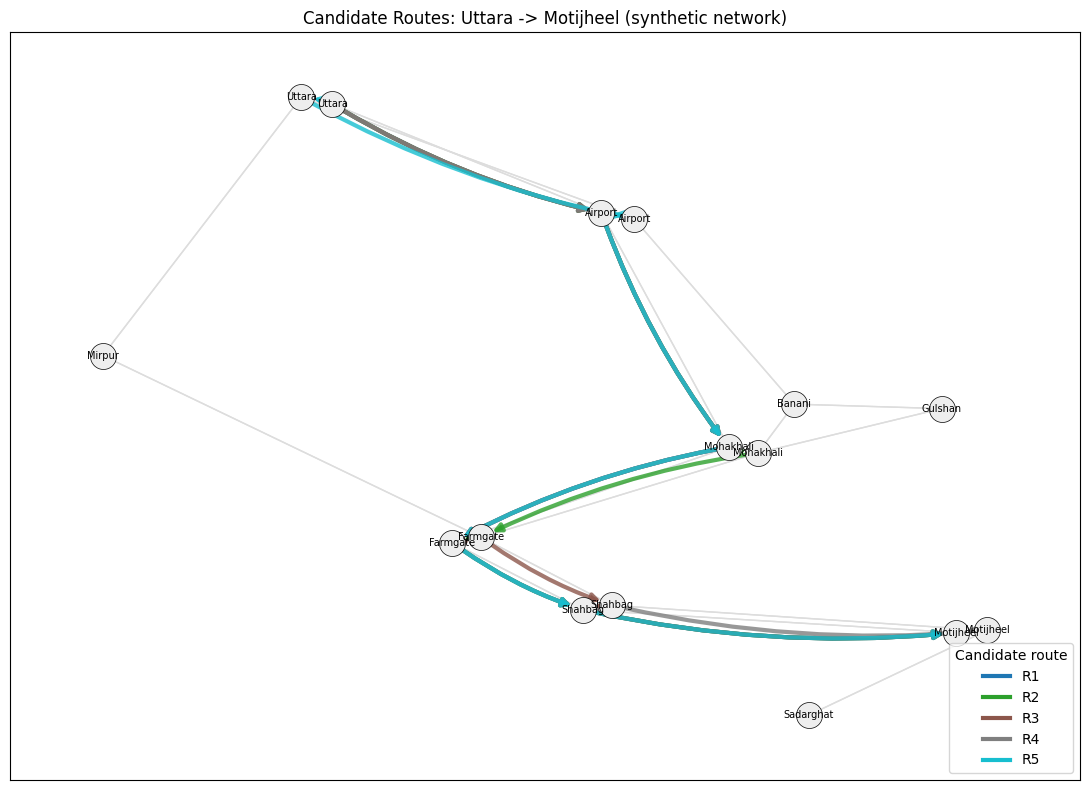

In [16]:
# --- 13.1 Candidate routes highlighted on the network -----------------------
plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(G, pos, edge_color="#dddddd", arrows=False, width=1)
nx.draw_networkx_nodes(G, pos, node_color="#eeeeee", node_size=350, edgecolors="black", linewidths=0.5)
nx.draw_networkx_labels(
    G, pos, labels={n: d["name"] for n, d in G.nodes(data=True)}, font_size=7
)

route_colors = plt.cm.tab10(np.linspace(0, 1, len(candidate_routes)))
for r, color in zip(candidate_routes, route_colors):
    path_edges = list(zip(r.path, r.path[1:]))
    nx.draw_networkx_edges(
        G, pos, edgelist=path_edges, edge_color=[color], width=3, alpha=0.8,
        arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.08",
    )

handles = [plt.Line2D([0], [0], color=route_colors[i], lw=3, label=f"R{i+1}")
           for i in range(len(candidate_routes))]
plt.legend(handles=handles, title="Candidate route", loc="lower right")
plt.title("Candidate Routes: Uttara -> Motijheel (synthetic network)")
plt.tight_layout()
plt.show()


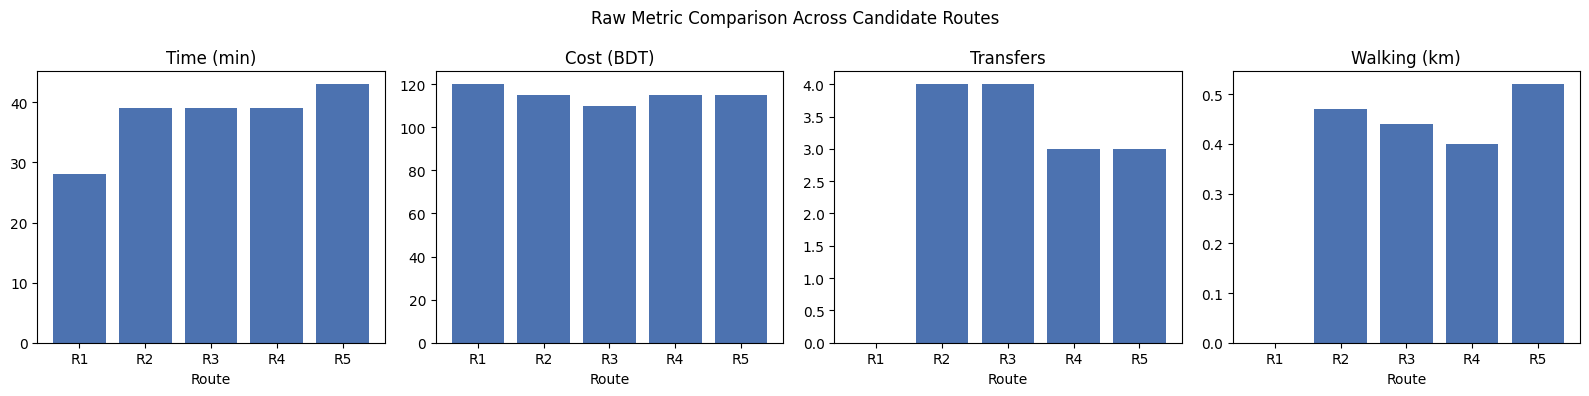

In [17]:
# --- 13.2 Raw metric comparison ---------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metric_cols = ["time_min", "cost_bdt", "transfers", "walk_km"]
metric_labels = ["Time (min)", "Cost (BDT)", "Transfers", "Walking (km)"]

for ax, col, label in zip(axes, metric_cols, metric_labels):
    ax.bar(metrics_df["route"], metrics_df[col], color="#4c72b0")
    ax.set_title(label)
    ax.set_xlabel("Route")

fig.suptitle("Raw Metric Comparison Across Candidate Routes")
plt.tight_layout()
plt.show()


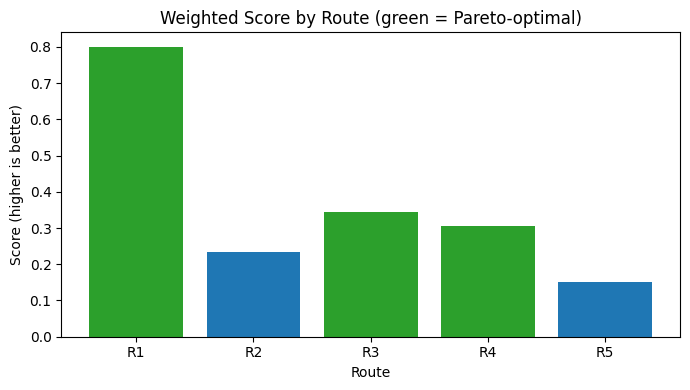

In [18]:
# --- 13.3 Weighted score comparison -----------------------------------------
plt.figure(figsize=(7, 4))
plot_df = ranked_df.sort_values("route")
colors = ["#2ca02c" if p else "#1f77b4" for p in pareto_mask]
plt.bar(plot_df["route"], plot_df["score"], color=colors)
plt.title("Weighted Score by Route (green = Pareto-optimal)")
plt.ylabel("Score (higher is better)")
plt.xlabel("Route")
plt.tight_layout()
plt.show()


## 14. Sensitivity Analysis

Because the objective is a weighted sum, changing the weights can change which
route ranks first. Below we compare the top-ranked route under three different
traveler profiles:

* **Fastest journey** — `time = 0.70`
* **Cheapest journey** — `cost = 0.60`
* **Low-transfer journey** — `transfers = 0.60`

(the remaining weight in each profile is split evenly across the other three
criteria, and all weight sets sum to 1.0).


In [19]:
def make_weight_profile(dominant: str, dominant_weight: float) -> Dict[str, float]:
    keys = ["time", "cost", "transfers", "walking"]
    remaining = 1.0 - dominant_weight
    other_keys = [k for k in keys if k != dominant]
    share = remaining / len(other_keys)
    profile = {k: share for k in other_keys}
    profile[dominant] = dominant_weight
    return profile

profiles = {
    "Balanced (default)": default_weights,
    "Fastest journey": make_weight_profile("time", 0.70),
    "Cheapest journey": make_weight_profile("cost", 0.60),
    "Low-transfer journey": make_weight_profile("transfers", 0.60),
}

sensitivity_rows = []
for profile_name, w in profiles.items():
    scored = score_routes(metrics_df, w)
    top = scored.sort_values("score", ascending=False).iloc[0]
    sensitivity_rows.append({
        "profile": profile_name,
        "weights": w,
        "top_route": top["route"],
        "mode_sequence": top["mode_sequence"],
        "time_min": top["time_min"],
        "cost_bdt": top["cost_bdt"],
        "transfers": top["transfers"],
        "walk_km": top["walk_km"],
        "score": round(top["score"], 3),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,profile,weights,top_route,mode_sequence,time_min,cost_bdt,transfers,walk_km,score
0,Balanced (default),"{'time': 0.45, 'cost': 0.2, 'transfers': 0.2, ...",R1,metro,28.0,120.0,0,0.00,0.800
1,Fastest journey,"{'cost': 0.10000000000000002, 'transfers': 0.1...",R1,metro,28.0,120.0,0,0.00,0.900
2,Cheapest journey,"{'time': 0.13333333333333333, 'transfers': 0.1...",R3,metro -> walk -> bus -> walk -> metro,39.0,110.0,4,0.44,0.656
3,Low-transfer journey,"{'time': 0.13333333333333333, 'cost': 0.133333...",R1,metro,28.0,120.0,0,0.00,0.867


**Observation.** As the weight distribution shifts toward a single criterion,
the top-ranked candidate can change (or stay the same, if one route happens to
dominate broadly). This is expected and desirable: it demonstrates that the
planner is genuinely preference-sensitive rather than always returning the plain
Dijkstra time-shortest path.


## 15. Algorithm Justification

| Component | Algorithm | Why |
|---|---|---|
| Baseline single-source routing | **Dijkstra** | Edge weights (time/cost/distance) are always non-negative; Dijkstra is the optimal, well-understood choice for this setting, running in O((V+E) log V). |
| Candidate route generation | **Yen's K-shortest paths** (`nx.shortest_simple_paths`) | Produces multiple *loopless* alternative routes ordered by weight, which is exactly what a multi-criteria comparison needs — a single shortest path is not enough. |
| Route ranking | **Weighted multi-criteria scoring** (normalized weighted sum) | Lets a configurable set of user preferences (time/cost/transfers/walking) determine the "best" route instead of a single hard-coded metric. |
| Multi-objective trade-off analysis | **Pareto dominance** | Identifies the subset of candidates that cannot be unambiguously improved on every metric simultaneously — a preference-independent view of "reasonable" choices. |

### Why the alternatives were **not** chosen as the primary algorithm here

- **BFS** — optimal only for unweighted graphs (fewest edges), not for
  minimizing time/cost/distance. Our edges have materially different weights, so
  BFS would frequently return a suboptimal journey.
- **DFS** — has no shortest-path optimality guarantee at all; it is a graph
  traversal strategy, not a routing algorithm.
- **Bellman-Ford** — correctly handles negative weights and detects negative
  cycles, at O(V·E) cost. Our transit weights are never negative, so this
  generality is unnecessary overhead versus Dijkstra.
- **A\*** — a strong candidate for a *production* single-pair query engine, using
  a geographic (haversine-based) heuristic to prune search space and answer
  faster at large scale. For this notebook's small demonstration graph the
  speed difference versus Dijkstra is negligible, so plain Dijkstra was kept for
  clarity; A\* is noted as a natural production optimization (Section 17).
- **Floyd-Warshall** — computes all-pairs shortest paths in O(V³), which is
  wasteful when we only need routes between a *specific* origin/destination pair
  (or a modest number of such queries) rather than the full all-pairs matrix.
- **Genetic Algorithms** — a metaheuristic suited to very large, poorly
  structured, or non-differentiable multi-objective search spaces where exact
  methods are impractical. Our candidate space is small and well-structured
  enough that exact methods (Dijkstra + Yen's) already give provably-good,
  reproducible results without the stochastic variability and tuning overhead
  of a GA.
- **Reinforcement Learning** — appropriate for *sequential decision-making under
  uncertainty with feedback* (e.g. learning a routing/dispatch policy from
  outcomes over time), which requires substantial historical interaction data we
  do not have. For a deterministic, fully-observed static graph, this is
  unnecessary complexity relative to exact graph algorithms.


## 16. Current Algorithmic Components vs. Future ML Components

The project is named "AI-Powered", but **this prototype's routing core is
entirely deterministic graph algorithms** — no model is trained or required for
correct, explainable route computation on a known graph. It is important not to
force machine learning into a component that does not need it.

**Current prototype (this notebook):**
- Graph construction & representation (NetworkX)
- Dijkstra's algorithm (baseline shortest path)
- Yen's K-shortest paths (candidate generation)
- Multi-criteria normalized weighted scoring
- Pareto dominance analysis

**Future ML components (not implemented here, and not claimed to exist):**
- **Travel-time prediction** — learning real segment travel times from historical
  GPS/AVL data instead of assuming fixed synthetic times.
- **Demand prediction** — forecasting how many riders will want a given
  origin-destination pair at a given time, to inform capacity/frequency.
- **Congestion prediction** — predicting how road/traffic conditions will affect
  bus travel time at a given hour.
- **Personalized route ranking** — learning a rider's implicit weight
  preferences from their past choices, instead of using fixed default weights.
- **ETA prediction** — real-time arrival estimation using live vehicle position
  data.

### Why ML is not required for the baseline routing engine
Given a graph with known (even if imperfect) edge weights, computing an optimal or
near-optimal route is a **well-defined combinatorial optimization problem** with
exact, efficient, and *explainable* algorithms (Dijkstra, Yen's). Machine learning
becomes relevant only when the **inputs themselves** (travel time, demand,
congestion) are unknown and must be estimated from data — that is a data problem
layered *underneath* the routing engine, not a replacement for the routing
algorithm itself.


## Robustness: Invalid Input and No-Path Handling

A usable planner must not crash on bad input. The helper below wraps the full
pipeline (resolve stops -> generate candidates -> score -> rank) and handles:

- an origin or destination name that does not exist in the network,
- an origin and destination that are technically valid but have **no path**
  between them in the (directed) graph.


In [20]:
def plan_journey(origin_name: str, destination_name: str, k: int = 5,
                  weights: Optional[Dict[str, float]] = None,
                  origin_mode: Optional[str] = None,
                  dest_mode: Optional[str] = None) -> Optional[pd.DataFrame]:
    """End-to-end planning pipeline with basic input validation and error handling.

    Returns a ranked DataFrame of candidate routes, or None if planning failed
    (an explanatory message is printed in that case).
    """
    weights = weights or default_weights
    try:
        o_id = resolve_stop(origin_name, mode=origin_mode)
        d_id = resolve_stop(destination_name, mode=dest_mode)
    except ValueError as exc:
        print(f"[Input error] {exc}")
        return None

    if o_id == d_id:
        print("[Input error] Origin and destination resolve to the same stop.")
        return None

    routes = k_shortest_routes(G, o_id, d_id, k=k, weight="time")
    if not routes:
        print(f"[No path] No route exists between "
              f"'{origin_name}' and '{destination_name}' in the current network.")
        return None

    m_df = routes_to_dataframe(routes)
    s_df = score_routes(m_df, weights)
    r_df = s_df.sort_values("score", ascending=False).reset_index(drop=True)
    r_df.insert(0, "rank", r_df.index + 1)
    return r_df


# --- Demonstrate graceful handling of bad input ------------------------------
print("Case 1: unknown origin name")
plan_journey("Nonexistent Place", "Motijheel")

print("\nCase 2: valid stops, but only checking no-path robustness on an isolated demo node")
# Add a temporary isolated node to demonstrate the no-path branch, then remove it.
G.add_node("ISOLATED_DEMO", name="Isolated Demo Stop", mode="bus", lat=0, lon=0)
stops_backup = stops.copy()
stops.loc[len(stops)] = ["ISOLATED_DEMO", "Isolated Demo Stop", 0, 0, "bus"]
plan_journey("Isolated Demo Stop", "Motijheel")
G.remove_node("ISOLATED_DEMO")
stops = stops_backup


Case 1: unknown origin name
[Input error] Unknown stop or station: 'Nonexistent Place'

Case 2: valid stops, but only checking no-path robustness on an isolated demo node
[No path] No route exists between 'Isolated Demo Stop' and 'Motijheel' in the current network.


## 17. Final Demonstration — Uttara to Motijheel

Bringing the full pipeline together for the headline example route requested for
this project, using the default "balanced" weight profile.


In [21]:
final_result = plan_journey("Uttara", "Motijheel", k=5,
                              weights=default_weights,
                              origin_mode="metro", dest_mode="metro")
final_result[["rank", "route", "mode_sequence", "time_min", "cost_bdt",
              "transfers", "walk_km", "score"]]


,rank,route,mode_sequence,time_min,cost_bdt,transfers,walk_km,score
0,1,R1,metro,28.0,120.0,0,0.00,0.800000
1,2,R3,metro -> walk -> bus -> walk -> metro,39.0,110.0,4,0.44,0.343077
2,3,R4,metro -> walk -> bus -> walk,39.0,115.0,3,0.40,0.304615
3,4,R2,metro -> walk -> bus -> walk -> metro,39.0,115.0,4,0.47,0.234423
4,5,R5,walk -> bus -> walk -> metro,43.0,115.0,3,0.52,0.150000


In [22]:
# --- Human-readable recommended-journey summary ------------------------------
best = final_result.iloc[0]
best_route_index = int(best["route"].replace("R", "")) - 1
best_route_obj = candidate_routes[best_route_index]

stop_names = [G.nodes[n]["name"] for n in best_route_obj.path]

print("=" * 60)
print("RECOMMENDED JOURNEY  (synthetic demonstration network)")
print("=" * 60)
print(" -> ".join(stop_names))
print()
print("Mode sequence:   " + " -> ".join(best_route_obj.mode_sequence))
print(f"Estimated time:  {best_route_obj.total_time:.0f} minutes")
print(f"Estimated cost:  {best_route_obj.total_cost:.0f} BDT")
print(f"Transfers:       {best_route_obj.num_transfers}")
print(f"Walking:         {best_route_obj.walking_distance:.2f} km")
print(f"Score:           {best['score']:.3f}  (weights: {default_weights})")
print("=" * 60)
print("NOTE: All figures above come from the SYNTHETIC demonstration network")
print("defined in Section 4 and do not represent real Dhaka transit data.")


RECOMMENDED JOURNEY  (synthetic demonstration network)
Uttara -> Airport -> Mohakhali -> Farmgate -> Shahbag -> Motijheel

Mode sequence:   metro
Estimated time:  28 minutes
Estimated cost:  120 BDT
Transfers:       0
Walking:         0.00 km
Score:           0.800  (weights: {'time': 0.45, 'cost': 0.2, 'transfers': 0.2, 'walking': 0.15})
NOTE: All figures above come from the SYNTHETIC demonstration network
defined in Section 4 and do not represent real Dhaka transit data.


## 18. Final Analysis

### What this prototype proves
- A single multimodal graph can represent walking, bus, and metro legs together,
  including realistic mode-transfer points, using a small and clean data model
  (3 edge attributes, 1 node attribute set).
- Dijkstra and Yen's K-shortest paths generate a diverse, ranked set of candidate
  journeys efficiently and deterministically from that graph.
- A normalized, weighted multi-criteria scoring function turns four
  differently-scaled metrics (time, cost, transfers, walking distance) into a
  single, *configurable* ranking — and changing the weights measurably changes
  which route is recommended (Section 14).
- Pareto analysis independently confirms which candidates represent genuinely
  distinct, non-dominated trade-offs, giving a preference-independent sanity
  check on the weighted ranking.
- The pipeline degrades gracefully (clear error messages, no crashes) on invalid
  stop names and on origin/destination pairs with no path.

### What it does NOT prove
- That the specific travel times, costs, or connectivity reflect real Dhaka
  transit operations — the dataset is entirely synthetic and clearly labelled as
  such throughout.
- That the default weights (`time=0.45, cost=0.20, transfers=0.20, walking=0.15`)
  reflect actual rider preferences — they are an illustrative prototype default,
  not a result derived from user research or optimization.
- That the system scales to a full city-scale graph with real-time conditions —
  this notebook uses a 16-node network for clarity, not a production-scale
  dataset.
- Anything about ML-based prediction — no model is trained here; Section 16
  explicitly separates what is implemented from what would require future data
  and ML work.

### Production roadmap
To evolve this prototype toward a real Bangladesh multimodal transit planner:

1. **Real data ingestion** — Ingest official schedules via **GTFS**/
   **GTFS-Realtime** feeds, where and when transit authorities publish them.
2. **Live vehicle data** — Incorporate GPS/AVL (Automatic Vehicle Location)
   telemetry from buses, where available, to replace static travel-time
   estimates with live ones.
3. **Traffic and weather context** — Integrate third-party traffic and weather
   APIs to adjust bus travel-time estimates for road conditions (metro is largely
   insulated from road traffic, but buses are not).
4. **ML-based travel-time and congestion prediction** — Train models on
   historical AVL/GTFS-Realtime data to predict segment travel times, replacing
   the fixed synthetic weights used here.
5. **Demand forecasting** — Model expected passenger volumes by
   origin-destination-time to support capacity-aware recommendations (e.g.
   warning about a likely-crowded bus).
6. **User preference learning** — Learn a rider's implicit weight profile
   (time/cost/transfer/walking sensitivity) from their historical route choices,
   rather than relying on a single fixed default.
7. **Dynamic re-routing** — Recompute recommendations mid-journey in response to
   real-time disruptions (e.g. a bus breakdown or metro delay).

None of the data sources above are assumed to currently exist or be accessible for
this project; they are listed only as a roadmap for what a production system would
require.
